In [59]:
import geopandas as gpd
import pandas as pd
import os

In [60]:
lsoa = gpd.read_file('data/LSOA_2011_EW_BFC_V3.shp')
print(lsoa.columns.tolist())
print(lsoa.head())

['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID', 'geometry']
    LSOA11CD                   LSOA11NM   BNG_E   BNG_N     LONG_      LAT  \
0  E01000001        City of London 001A  532123  181632 -0.097140  51.5182   
1  E01000002        City of London 001B  532480  181715 -0.091970  51.5188   
2  E01000003        City of London 001C  532239  182033 -0.095320  51.5217   
3  E01000005        City of London 001E  533581  181283 -0.076270  51.5147   
4  E01000006  Barking and Dagenham 016A  544994  184274  0.089317  51.5387   

    Shape_Leng                              GlobalID  \
0  2635.767993  eaf9e4b8-fcc1-4cae-a46c-22c8a43ff39b   
1  2707.881853  4434ca6e-e270-4e88-b3eb-4cfb37f62490   
2  1224.638192  d0ff9760-86dc-40da-ad33-3b1dc987ef04   
3  2275.805348  474caa9f-a6e3-4de2-8bc1-2f5b0da40271   
4  1966.092607  ff2bc9a6-9e26-4415-9cec-eaea2c0a4f54   

                                            geometry  
0  POLYGON ((532151.537 181867.433, 532152

Swansea LSOAs: 148


<Axes: >

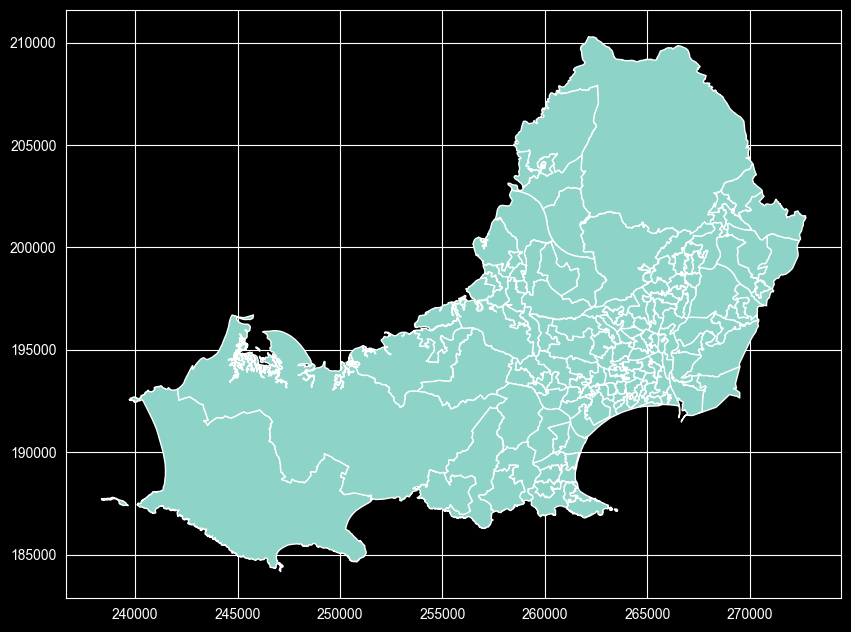

In [61]:
swansea_lsoa = lsoa[lsoa['LSOA11NM'].str.startswith('Swansea')].copy()
print(f'Swansea LSOAs: {len(swansea_lsoa)}')
swansea_lsoa.plot(figsize=(10,8))

In [62]:
wimd = pd.read_excel('data/WIMD2019Swansea.xlsx')
print(wimd.columns.tolist())
wimd.columns = wimd.columns.str.strip()
print(wimd.columns.tolist())
print(wimd.shape)

['LSOA Code', 'LSOA Name', 'WIMD 2019 ', 'Income ', 'Employment', 'Health', 'Education ', 'Access to Services', 'Housing', 'Community Safety', 'Physical Environment']
['LSOA Code', 'LSOA Name', 'WIMD 2019', 'Income', 'Employment', 'Health', 'Education', 'Access to Services', 'Housing', 'Community Safety', 'Physical Environment']
(148, 11)


In [63]:
merged = swansea_lsoa.merge(wimd, left_on='LSOA11CD', right_on='LSOA Code', how='left')
print(merged.shape)
print(merged['WIMD 2019'].isna().sum(), 'unmatched')

(148, 20)
0 unmatched


In [64]:
merged = merged.to_crs("EPSG:27700")
print(merged.crs)

EPSG:27700
